# LSTM 폐업률 예측 모델 - Google Colab

이 노트북은 Google Colab에서 LSTM 폐업률 예측 모델을 학습하고 평가합니다.

## 🚀 실행 방법
1. Google Colab에서 이 노트북 열기
2. 런타임 > 런타임 유형 변경 > GPU 선택 (선택사항)
3. 셀을 순서대로 실행 (Shift + Enter)

---

## 1. 환경 설정 및 데이터 업로드

In [1]:
# 필요 라이브러리 설치
!pip install -q tensorflow pandas numpy scikit-learn matplotlib seaborn

In [2]:
# Google Drive 마운트 (데이터 파일을 Drive에 업로드한 경우)
from google.colab import drive
drive.mount('/content/drive')

# 또는 직접 파일 업로드
# from google.colab import files
# uploaded = files.upload()

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pickle
import json
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks

print("TensorFlow 버전:", tf.__version__)
print("GPU 사용 가능:", tf.config.list_physical_devices('GPU'))

# 한글 폰트 설정
!apt-get install -y fonts-nanum
!fc-cache -fv
import matplotlib.font_manager as fm
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

TensorFlow 버전: 2.19.0
GPU 사용 가능: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 38 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (5,765 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 126675 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 f

## 2. 데이터 경로 설정

**중요**: `merged_data.csv` 파일 경로를 설정해주세요.

In [6]:
# 데이터 파일 경로 설정
# 방법 1: Google Drive 사용
DATA_PATH = '/content/merged_data.csv'

# 방법 2: 직접 업로드한 경우
# DATA_PATH = 'merged_data.csv'

# 파일 존재 확인
if os.path.exists(DATA_PATH):
    print(f"✓ 데이터 파일 발견: {DATA_PATH}")
    df_check = pd.read_csv(DATA_PATH, nrows=5)
    print(f"  - Shape: {df_check.shape}")
    print(f"  - Columns: {len(df_check.columns)}")
else:
    print(f"✗ 데이터 파일을 찾을 수 없습니다: {DATA_PATH}")
    print("  파일을 업로드하거나 경로를 수정해주세요.")

✓ 데이터 파일 발견: /content/merged_data.csv
  - Shape: (5, 137)
  - Columns: 137


## 3. 데이터 전처리 및 시퀀스 생성

In [7]:
class LSTMPreprocessor:
    def __init__(self, data_path, look_back=4):
        self.data_path = data_path
        self.look_back = look_back
        self.scaler = StandardScaler()
        self.label_encoders = {}

    def load_data(self):
        print("=" * 80)
        print("1. 데이터 로딩...")
        print("=" * 80)
        self.df = pd.read_csv(self.data_path)
        print(f"데이터 크기: {self.df.shape}")
        return self

    def preprocess_features(self):
        print("\n" + "=" * 80)
        print("2. 특성 전처리...")
        print("=" * 80)

        self.df = self.df.fillna(0)

        categorical_cols = ['자치구_코드_명', '서비스_업종_코드_명', '상권_변화_지표']
        for col in categorical_cols:
            if col in self.df.columns:
                le = LabelEncoder()
                self.df[f'{col}_encoded'] = le.fit_transform(self.df[col].astype(str))
                self.label_encoders[col] = le

        unique_quarters = sorted(self.df['기준_년분기_코드'].unique())
        self.quarter_to_idx = {q: i for i, q in enumerate(unique_quarters)}
        self.df['quarter_idx'] = self.df['기준_년분기_코드'].map(self.quarter_to_idx)
        self.df = self.df.sort_values(['자치구_코드_명_encoded', '서비스_업종_코드_명_encoded', 'quarter_idx'])

        print(f"  - 전처리 완료: {self.df.shape}")
        return self

    def select_features(self):
        print("\n" + "=" * 80)
        print("3. 특성 선택...")
        print("=" * 80)

        exclude_cols = [
            '기준_년분기_코드', '자치구_코드_명', '서비스_업종_코드_명', '상권_변화_지표',
            '폐업_률', '폐업_점포_수', 'quarter_idx'
        ]

        numeric_cols = self.df.select_dtypes(include=[np.number]).columns.tolist()
        self.feature_cols = [col for col in numeric_cols if col not in exclude_cols]
        self.feature_cols.extend(['자치구_코드_명_encoded', '서비스_업종_코드_명_encoded', '상권_변화_지표_encoded'])

        print(f"  - 선택된 특성 수: {len(self.feature_cols)}")
        return self

    def create_sequences(self):
        print("\n" + "=" * 80)
        print(f"4. 시퀀스 생성 (Look-back: {self.look_back} 분기)...")
        print("=" * 80)

        X_sequences = []
        y_sequences = []
        metadata = []

        groups = self.df.groupby(['자치구_코드_명_encoded', '서비스_업종_코드_명_encoded'])

        for (district, industry), group in groups:
            group = group.sort_values('quarter_idx')
            if len(group) <= self.look_back:
                continue

            for i in range(len(group) - self.look_back):
                X_seq = group.iloc[i:i+self.look_back][self.feature_cols].values
                y_val = group.iloc[i+self.look_back]['폐업_률']

                X_sequences.append(X_seq)
                y_sequences.append(y_val)
                metadata.append({
                    'district': district,
                    'industry': industry,
                    'quarter': group.iloc[i+self.look_back]['기준_년분기_코드']
                })

        self.X = np.array(X_sequences)
        self.y = np.array(y_sequences)
        self.metadata = pd.DataFrame(metadata)

        print(f"  - 생성된 시퀀스 수: {len(self.X)}")
        print(f"  - X shape: {self.X.shape}")
        return self

    def scale_features(self):
        print("\n" + "=" * 80)
        print("5. 특성 스케일링...")
        print("=" * 80)

        n_samples, n_timesteps, n_features = self.X.shape
        X_reshaped = self.X.reshape(-1, n_features)
        X_scaled = self.scaler.fit_transform(X_reshaped)
        self.X_scaled = X_scaled.reshape(n_samples, n_timesteps, n_features)

        print(f"  - 스케일링 완료: {self.X_scaled.shape}")
        return self

    def split_data(self, train_ratio=0.7, val_ratio=0.15):
        print("\n" + "=" * 80)
        print("6. 데이터 분할...")
        print("=" * 80)

        unique_quarters = sorted(self.metadata['quarter'].unique())
        n_quarters = len(unique_quarters)

        train_end = int(n_quarters * train_ratio)
        val_end = train_end + int(n_quarters * val_ratio)

        train_quarters = unique_quarters[:train_end]
        val_quarters = unique_quarters[train_end:val_end]
        test_quarters = unique_quarters[val_end:]

        train_idx = self.metadata['quarter'].isin(train_quarters)
        val_idx = self.metadata['quarter'].isin(val_quarters)
        test_idx = self.metadata['quarter'].isin(test_quarters)

        self.X_train = self.X_scaled[train_idx]
        self.y_train = self.y[train_idx]
        self.X_val = self.X_scaled[val_idx]
        self.y_val = self.y[val_idx]
        self.X_test = self.X_scaled[test_idx]
        self.y_test = self.y[test_idx]

        print(f"  - Train: {len(self.X_train)} samples")
        print(f"  - Val: {len(self.X_val)} samples")
        print(f"  - Test: {len(self.X_test)} samples")
        return self

# 전처리 실행
preprocessor = LSTMPreprocessor(DATA_PATH, look_back=4)
preprocessor.load_data() \
            .preprocess_features() \
            .select_features() \
            .create_sequences() \
            .scale_features() \
            .split_data()

print("\n✓ 전처리 완료!")

1. 데이터 로딩...
데이터 크기: (39975, 137)

2. 특성 전처리...
  - 전처리 완료: (39975, 141)

3. 특성 선택...
  - 선택된 특성 수: 137

4. 시퀀스 생성 (Look-back: 4 분기)...
  - 생성된 시퀀스 수: 33768
  - X shape: (33768, 4, 137)

5. 특성 스케일링...
  - 스케일링 완료: (33768, 4, 137)

6. 데이터 분할...
  - Train: 23039 samples
  - Val: 4602 samples
  - Test: 6127 samples

✓ 전처리 완료!


## 4. LSTM 모델 구축 및 학습

In [8]:
# 모델 구축
def build_lstm_model(n_timesteps, n_features, lstm_units=[128, 64], dropout_rate=0.3):
    model = models.Sequential()

    model.add(layers.LSTM(lstm_units[0], return_sequences=True, input_shape=(n_timesteps, n_features)))
    model.add(layers.Dropout(dropout_rate))

    model.add(layers.LSTM(lstm_units[1]))
    model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dropout(dropout_rate / 2))

    model.add(layers.Dense(1))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse')]
    )

    return model

# 모델 생성
n_timesteps = preprocessor.X_train.shape[1]
n_features = preprocessor.X_train.shape[2]

model = build_lstm_model(n_timesteps, n_features)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 4, 128)         │       136,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 187,713 (733.25 KB)

 Trainable params: 187,713 (733.25 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# 콜백 설정
callback_list = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-7,
        verbose=1
    )
]

# 학습
print("=" * 80)
print("모델 학습 시작...")
print("=" * 80)

history = model.fit(
    preprocessor.X_train, preprocessor.y_train,
    validation_data=(preprocessor.X_val, preprocessor.y_val),
    epochs=100,
    batch_size=32,
    callbacks=callback_list,
    verbose=1
)

print("\n✓ 학습 완료!")

모델 학습 시작...
Epoch 1/100
720/720 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 4.0945 - mae: 1.4572 - rmse: 2.0103 - val_loss: 3.3883 - val_mae: 1.2392 - val_rmse: 1.8407 - learning_rate: 0.0010
Epoch 2/100
720/720 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 3.1446 - mae: 1.2436 - rmse: 1.7726 - val_loss: 3.4894 - val_mae: 1.2491 - val_rmse: 1.8680 - learning_rate: 0.0010
Epoch 3/100
720/720 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 3.1729 - mae: 1.2313 - rmse: 1.7807 - val_loss: 3.4193 - val_mae: 1.2469 - val_rmse: 1.8491 - learning_rate: 0.0010
Epoch 4/100
720/720 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 3.0662 - mae: 1.2133 - rmse: 1.7504 - val_loss: 3.4119 - val_mae: 1.2226 - val_rmse: 1.8471 - learning_rate: 0.0010
Epoch 5/100
720/720 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 2.9948 - mae: 1.2011 - rmse: 1.7302 - val_loss: 3.4092 - val_mae: 1.2260 - val_rmse: 1.8464 - learning_rate: 0.0010
Epoch 6/100
720/720 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 2.8137 - mae: 1.1751 - rmse: 1.6769 - va

## 5. 모델 평가

In [10]:
# 테스트 세트 평가
print("=" * 80)
print("모델 평가 (Test Set)")
print("=" * 80)

test_results = model.evaluate(preprocessor.X_test, preprocessor.y_test, verbose=0)
y_pred = model.predict(preprocessor.X_test, verbose=0).flatten()

# 평가 지표
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(preprocessor.y_test, y_pred)
mse = mean_squared_error(preprocessor.y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(preprocessor.y_test, y_pred)

mask = preprocessor.y_test != 0
mape = np.mean(np.abs((preprocessor.y_test[mask] - y_pred[mask]) / preprocessor.y_test[mask])) * 100

print(f"\nMSE:  {mse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

print("\n실제값 vs 예측값 통계:")
print(f"  실제 평균: {np.mean(preprocessor.y_test):.2f}% ± {np.std(preprocessor.y_test):.2f}%")
print(f"  예측 평균: {np.mean(y_pred):.2f}% ± {np.std(y_pred):.2f}%")

모델 평가 (Test Set)

MSE:  2.7155
MAE:  1.2011
RMSE: 1.6479
R²:   0.2373
MAPE: 52.26%

실제값 vs 예측값 통계:
  실제 평균: 2.59% ± 1.89%
  예측 평균: 2.66% ± 1.02%


## 6. 시각화

/tmp/ipython-input-2531775036.py:28: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2531775036.py:28: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2531775036.py:28: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2531775036.py:28: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12

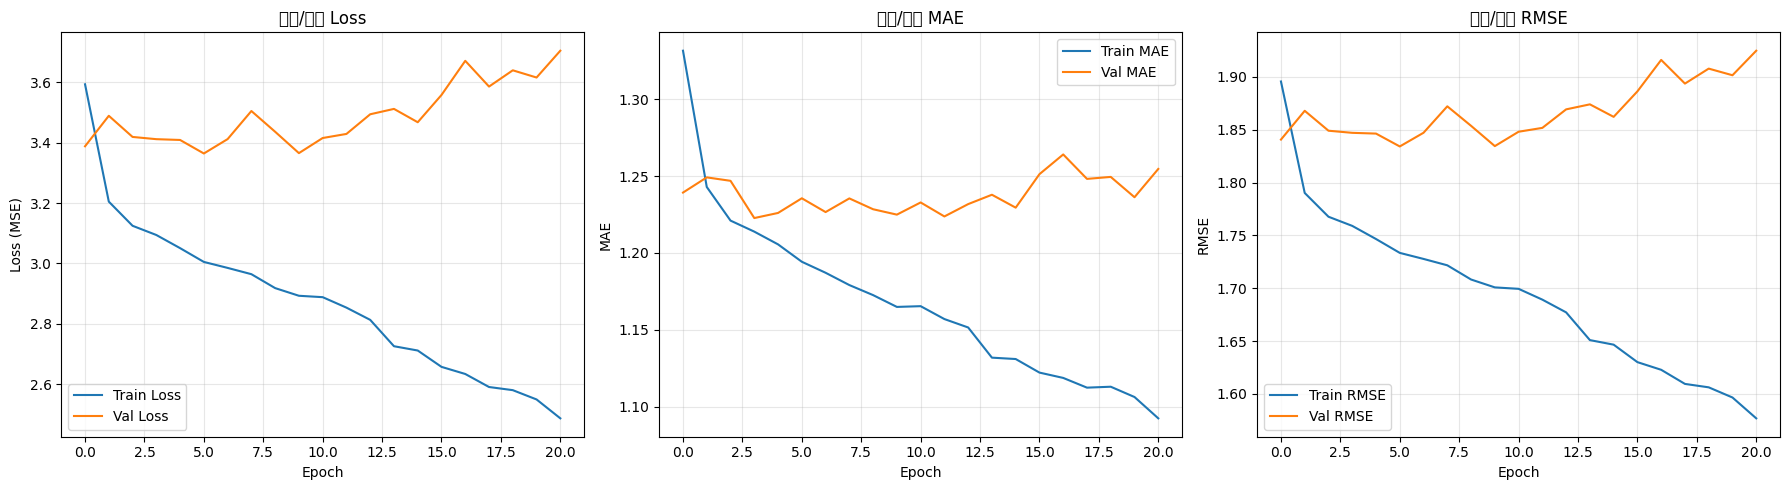

In [11]:
# 학습 히스토리
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('학습/검증 Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('학습/검증 MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history.history['rmse'], label='Train RMSE')
axes[2].plot(history.history['val_rmse'], label='Val RMSE')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('RMSE')
axes[2].set_title('학습/검증 RMSE')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 예측 결과 시각화
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Scatter plot
axes[0, 0].scatter(preprocessor.y_test, y_pred, alpha=0.5, s=20)
axes[0, 0].plot([preprocessor.y_test.min(), preprocessor.y_test.max()],
                [preprocessor.y_test.min(), preprocessor.y_test.max()],
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('실제 폐업률 (%)')
axes[0, 0].set_ylabel('예측 폐업률 (%)')
axes[0, 0].set_title('실제값 vs 예측값')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. 잔차 플롯
residuals = preprocessor.y_test - y_pred
axes[0, 1].scatter(y_pred, residuals, alpha=0.5, s=20)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('예측 폐업률 (%)')
axes[0, 1].set_ylabel('잔차')
axes[0, 1].set_title('잔차 플롯')
axes[0, 1].grid(True, alpha=0.3)

# 3. 시계열 비교
n_samples = min(200, len(preprocessor.y_test))
indices = np.arange(n_samples)
axes[1, 0].plot(indices, preprocessor.y_test[:n_samples], 'o-', label='실제값', alpha=0.7, markersize=4)
axes[1, 0].plot(indices, y_pred[:n_samples], 's-', label='예측값', alpha=0.7, markersize=4)
axes[1, 0].set_xlabel('샘플 인덱스')
axes[1, 0].set_ylabel('폐업률 (%)')
axes[1, 0].set_title(f'시계열 비교 (처음 {n_samples}개)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. 오차 분포
axes[1, 1].hist(residuals, bins=50, alpha=0.7, edgecolor='black')
axes[1, 1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('잔차')
axes[1, 1].set_ylabel('빈도')
axes[1, 1].set_title('오차 분포')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 정확도 분석
abs_errors = np.abs(residuals)

print("=" * 80)
print("정확도 분석")
print("=" * 80)

within_0_5 = np.sum(abs_errors <= 0.5) / len(abs_errors) * 100
within_1_0 = np.sum(abs_errors <= 1.0) / len(abs_errors) * 100
within_2_0 = np.sum(abs_errors <= 2.0) / len(abs_errors) * 100
within_3_0 = np.sum(abs_errors <= 3.0) / len(abs_errors) * 100

print(f"오차 ±0.5% 이내: {within_0_5:.1f}%")
print(f"오차 ±1.0% 이내: {within_1_0:.1f}%")
print(f"오차 ±2.0% 이내: {within_2_0:.1f}%")
print(f"오차 ±3.0% 이내: {within_3_0:.1f}%")

## 7. 모델 저장 (선택사항)

In [ ]:
# # 모델 저장
# timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
# model_path = f'lstm_closure_model_{timestamp}.keras'

# model.save(model_path)
# print(f"✓ 모델 저장: {model_path}")

# # Google Drive에 저장 (선택사항)
# # model.save(f'/content/drive/MyDrive/{model_path}')

# # 스케일러 저장
# with open('scaler.pkl', 'wb') as f:
#     pickle.dump(preprocessor.scaler, f)
# print("✓ Scaler 저장: scaler.pkl")

## 8. 새로운 데이터로 예측 (예시)

In [ ]:
# 예측 예시
sample_idx = 0
sample_X = preprocessor.X_test[sample_idx:sample_idx+1]
sample_y_true = preprocessor.y_test[sample_idx]
sample_y_pred = model.predict(sample_X, verbose=0)[0, 0]

print("=" * 80)
print("예측 예시")
print("=" * 80)
print(f"실제 폐업률: {sample_y_true:.2f}%")
print(f"예측 폐업률: {sample_y_pred:.2f}%")
print(f"오차: {abs(sample_y_true - sample_y_pred):.2f}%")